In [ ]:
# 1. IMPORT LIBRARIES

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# 2. LOAD DATASET

df = pd.read_csv("Tweets.csv")

df.columns = df.columns.str.strip()

print("Columns:", df.columns)
df.head()

Columns: Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
# 3. DATA PREPROCESSING

TEXT_COL = "selected_text"
LABEL_COL = "sentiment"

df = df[[TEXT_COL, LABEL_COL]].dropna()

# small sample because system is heavy
df = df.sample(200, random_state=42)

texts = df[TEXT_COL].astype(str).tolist()

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

labels = [label_map[x] for x in df[LABEL_COL]]

In [ ]:
# 4. TOKENIZATION

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# 5. DATASET CLASS

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


dataset = TweetDataset(encodings, labels)

In [ ]:
# 6. DATALOADER

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [ ]:
# 7. BERT MODEL

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# freeze BERT layers to make training light
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = AdamW(model.classifier.parameters(), lr=2e-5)

print("Device:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cpu


In [ ]:
# 8. TRAINING

epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = {key: value.to(device) for key, value in batch.items()}

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1} Loss: {total_loss / len(loader):.4f}")

Epoch 1 Loss: 1.1241


In [ ]:
# 9. PREDICTION FUNCTION

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def predict(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    print("Text:", text)
    print("Predicted Sentiment:", label_names[pred])

In [ ]:
# 10. ATTENTION VISUALIZATION

def visualize_attention(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attention = outputs.attentions[-1][0][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        attention,
        xticklabels=tokens,
        yticklabels=tokens,
        annot=True,
        cmap="coolwarm"   # changed color map
    )

    plt.title("Attention Heatmap")
    plt.xticks(rotation=90)
    plt.show()

Text: I love this phone but the battery is average
Predicted Sentiment: negative


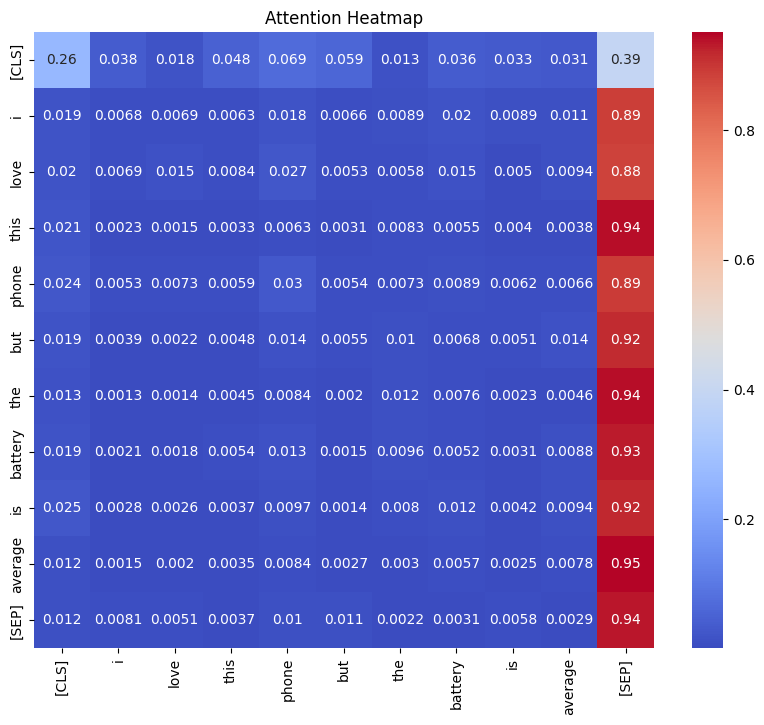

In [ ]:
# 11. TEST

test_tweet = "I love this phone but the battery is average"

predict(test_tweet)
visualize_attention(test_tweet)